# Gradientes e Backpropagation

Um motor de autodiff escrito do zero, e um passo de aprendizado numa rede
mínima com **embedding + linear**.

O motor (`Value`) e o desenhador de grafos (`draw_dot`) são a base do
[micrograd](https://github.com/karpathy/micrograd).

## Setup

`math` é usado pela `Value` (no `tanh` e no `exp`), `random` pelo MLP e
`torch` na comparação do final.

In [ ]:
import math
import random
import torch

## 1. A classe `Value`

Esta é a peça central do notebook inteiro. Um `Value` guarda quatro coisas:

- **`data`** — o número em si
- **`grad`** — a derivada da saída final em relação a este número. Começa em
  `0.0`, que quer dizer "ainda não calculado"
- **`_prev`** — de quais `Value` ele veio. É isso que forma o grafo
- **`_backward`** — uma função que sabe distribuir o gradiente para os pais

Repare no padrão que se repete em `__add__`, `__mul__`, `__pow__` e `tanh`:
cada operação cria o `Value` de saída **e** define o `_backward` dela. Toda a
derivada que existe no motor está nessas funções, e cada uma sabe derivar
uma operação só.

Na multiplicação, veja a simetria: a derivada em relação a um fator é o
**outro fator**.

```python
self.grad  += other.data * out.grad
other.grad += self.data  * out.grad
```

O `+=` em vez de `=` importa: se um `Value` é usado em vários lugares, os
gradientes de cada caminho **somam**.

No fim, o método `backward()`: ele ordena o grafo, põe `1.0` na raiz e chama
o `_backward` de cada nó de trás para frente. Backpropagation inteiro é
esse `for`.

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out


    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += (other*(self.data**(other-1))) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()



## 2. Desenhando o grafo

`trace` percorre o grafo a partir da raiz e coleta nós e arestas. `draw_dot`
transforma isso num diagrama: uma caixa por `Value`, mostrando rótulo,
`data` e `grad`, e um círculo para cada operação.

Como cada `Value` é um número escalar, **todo nó do desenho existe de fato
no grafo**. Nada é reconstruído para ficar bonito.

In [ ]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape= 'record')
        if n._op:
            #if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        #connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

## 3. Um neurônio à mão

Duas entradas, dois pesos, um bias, e `tanh` no fim. Cada operação é escrita
separadamente para que cada uma vire um nó com nome no diagrama.

O `o.backward()` na última linha preenche o `grad` de todo mundo.

In [ ]:
# isso é um neurônio
# inputs x1, x1
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w2 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()


O grafo completo, com os gradientes já calculados:

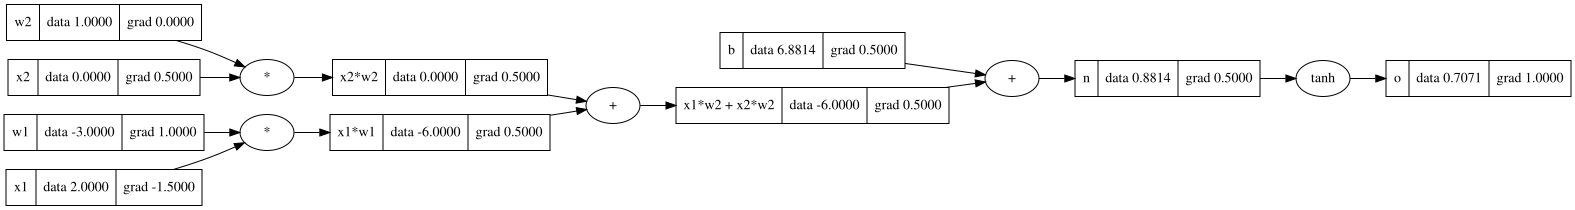

In [ ]:
draw_dot(o)

## 4. O mesmo neurônio, com o `tanh` aberto

Aqui o `tanh` é trocado pela fórmula dele, `(e^2n - 1)/(e^2n + 1)`, usando
`exp`, subtração e divisão.

O grafo fica maior — várias operações no lugar de uma. Mas o gradiente final
de `x1`, `w1`, `x2` e `w2` é **exatamente o mesmo**.

A lição: a granularidade do grafo é uma escolha de implementação. Você pode
tratar `tanh` como uma operação atômica ou abri-la em cinco; a regra da
cadeia dá o mesmo resultado.

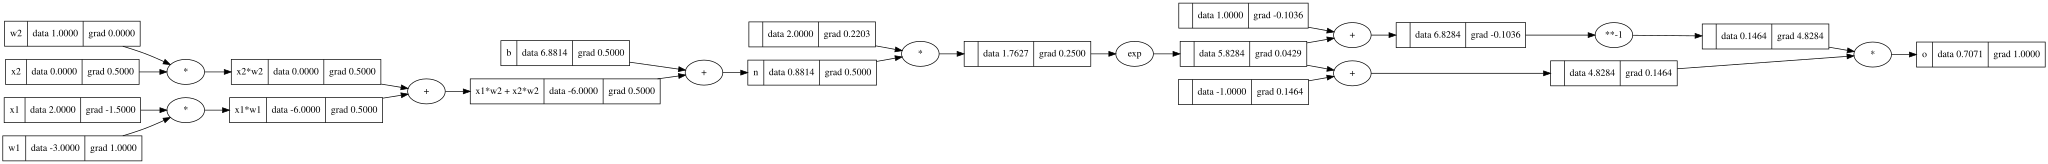

In [ ]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w2 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----------
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----------
o.label = 'o'
o.backward()
draw_dot(o)

## 5. Conferindo com o PyTorch

O mesmo neurônio, agora com tensores de verdade. `requires_grad = True` é o
que diz ao PyTorch para montar o grafo.

Compare os quatro gradientes impressos com os do diagrama acima. São os
mesmos números — o que prova que a `Value` não é uma simplificação didática,
é o mecanismo real.

In [ ]:

x1 = torch.Tensor([2.0]).double()                   ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                   ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                  ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                   ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()     ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("-------")
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
-------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## 6. Montando uma rede

Três classes empilhadas:

- **`Neuron`** — tem `nin` pesos e um bias, todos `Value` aleatórios. O
  `__call__` faz `w·x + b` e aplica `tanh`
- **`Layer`** — uma lista de neurônios que recebem a mesma entrada
- **`MLP`** — uma lista de camadas, onde a saída de uma é a entrada da
  seguinte

O método `parameters()` devolve todos os `Value` ajustáveis, achatados numa
lista só. É o equivalente ao `model.parameters()` do PyTorch.

In [ ]:
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            ps = layer.parameters()
            params.extend(ps)
        return params


Uma rede 3 → 4 → 4 → 1, com uma entrada de exemplo:

In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.7237214347958125)

## 7. Treinando

Quatro exemplos, cada um com sua saída desejada.

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

O loop de treino, com as quatro etapas nomeadas no código:

1. **forward** — as previsões e a loss (erro quadrático somado)
2. **zerar os gradientes** — sem isso eles acumulariam entre as iterações,
   por causa do `+=` lá no motor
3. **backward** — preenche o `.grad` de cada parâmetro
4. **update** — `p.data += -0.05 * p.grad`, o único lugar onde peso muda de
   valor

A loss impressa deve cair a cada iteração.

In [ ]:
for k in range(40):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update (gradient descent)
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 5.026593063541966
1 0.9312454662652296
2 0.5924143848070935
3 0.40977036661332467
4 0.3012076721718624
5 0.23128391310209834
6 0.18362003116938203
7 0.14953650354968148
8 0.12422659749669754
9 0.10487779310051065
10 0.089752793681863
11 0.0777229423984364
12 0.06802092721942829
13 0.06010440812473035
14 0.053577901948954926
15 0.04814615112864711
16 0.04358494278216134
17 0.03972191128115467
18 0.03642331231159501
19 0.03358457093664937
20 0.03112335182488149
21 0.028974395054889017
22 0.02708562863648316
23 0.025415222818492428
24 0.02392934698466926
25 0.022600454016115778
26 0.021405962234298317
27 0.020327237988266265
28 0.01934880632085375
29 0.0184577352871458
30 0.017643153024665684
31 0.016895866766453632
32 0.01620806052088541
33 0.015573053770328237
34 0.014985107753476844
35 0.014439269057420528
36 0.013931242625202359
37 0.013457288082746622
38 0.0130141346533485
39 0.012598910967743876


As previsões finais, que devem estar perto de `[1, -1, -1, 1]`:

In [ ]:
ypred

[Value(data=0.9479510425573306),
 Value(data=-0.9378547396671965),
 Value(data=-0.9399023583471191),
 Value(data=0.9508465964270524)]

# Entrega: um passo de aprendizado

Rede mínima com **embedding + linear**, construída com a `Value` acima.

Como a `Value` é escalar, o `draw_dot` desenha **cada peso e cada operação
que realmente existem** no grafo — nada é reconstruído para o desenho.

- vocabulário de 5 palavras
- embedding de dimensão 2
- camada linear para 2 classes
- loss = erro quadrático (mesma do treino do MLP acima)


### A rede

Três classes, no mesmo estilo do `Neuron`/`Layer`/`MLP` acima — e na mesma
forma do PyTorch: `__call__` faz o forward, `parameters()` devolve tudo que
é treinável.

- **`Embedding`** — a tabela. Uma linha por palavra. O `__call__` só indexa;
  não há conta nenhuma. Mas as linhas são `Value`, então recebem gradiente.
- **`Linear`** — dois neurônios, cada um com dois pesos e um bias.
- **`RedeMinima`** — junta as duas. `rede("gato")` faz lookup e depois a
  soma ponderada.

`rede.parameters()` devolve os 16 parâmetros das duas camadas juntos. É isso
que deixa o passo de atualização com uma linha só, mais adiante.

Os pesos são fixos em vez de aleatórios para os números serem sempre os
mesmos e você conseguir conferi-los na mão.

In [ ]:
VOCAB = ["o", "gato", "cachorro", "dorme", "corre"]

# pesos fixos em vez de aleatórios, para os números serem reproduzíveis
EMB_INIT = [[0.5, -0.2], [1.0, 0.5], [-0.5, 0.8], [0.2, 0.1], [-1.0, 0.3]]
W_INIT   = [[0.4, -0.6], [0.9, 0.3]]
B_INIT   = [0.1, -0.2]


class Embedding:
    """Primeira camada: uma tabela com uma linha por palavra.

    Não faz conta — devolve a linha. Mas as linhas são parâmetros:
    recebem gradiente e são atualizadas igual a qualquer peso.
    """

    def __init__(self, vocab, dim, init=None):
        self.vocab = vocab
        self.table = [
            [Value(init[r][c] if init else random.uniform(-1, 1),
                   label=f"emb[{vocab[r]}][{c}]")
             for c in range(dim)]
            for r in range(len(vocab))
        ]

    def __call__(self, palavra):
        return self.table[self.vocab.index(palavra)]

    def parameters(self):
        return [v for linha in self.table for v in linha]


class Linear:
    """Segunda camada: nout neurônios, cada um com nin pesos e um bias."""

    def __init__(self, nin, nout, W=None, b=None):
        self.W = [[Value(W[j][i] if W else random.uniform(-1, 1),
                         label=f"W[{j}][{i}]")
                   for i in range(nin)] for j in range(nout)]
        self.b = [Value(b[j] if b else 0.0, label=f"b[{j}]")
                  for j in range(nout)]

    def __call__(self, x):
        logits = []
        for j, (wj, bj) in enumerate(zip(self.W, self.b)):
            z = wj[0] * x[0]
            for i in range(1, len(x)):
                z = z + wj[i] * x[i]
            z = z + bj
            z.label = f"logit[{j}]"
            logits.append(z)
        return logits

    def parameters(self):
        return [v for linha in self.W for v in linha] + self.b


class RedeMinima:
    """Embedding + Linear. Mesma interface do MLP acima."""

    def __init__(self, vocab, dim, nout):
        self.emb = Embedding(vocab, dim, EMB_INIT)
        self.lin = Linear(dim, nout, W_INIT, B_INIT)

    def __call__(self, palavra):
        vetor = self.emb(palavra)      # lookup
        return self.lin(vetor)         # soma ponderada

    def parameters(self):
        return self.emb.parameters() + self.lin.parameters()

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0


def erro_quadratico(logits, alvo):
    """Compara os logits com o alvo em one-hot."""
    perdas = [(l - (1.0 if j == alvo else 0.0))**2 for j, l in enumerate(logits)]
    loss = perdas[0]
    for p in perdas[1:]:
        loss = loss + p
    loss.label = "loss"
    return loss

### Forward, e os gradientes antes

A loss já existe, mas todos os `grad` estão em `0.0`. Calcular a loss e
calcular os gradientes são duas coisas separadas — ninguém perguntou pelos
gradientes ainda.

In [ ]:
rede = RedeMinima(VOCAB, dim=2, nout=2)

logits = rede("gato")
loss = erro_quadratico(logits, alvo=1)

print("logits:", [round(l.data, 4) for l in logits])
print("loss:  ", round(loss.data, 6))
print("parâmetros da rede:", len(rede.parameters()))
print()

# ANTES do backward. Na micrograd o .grad nasce 0.0;
# no PyTorch nasce None. Os dois querem dizer "ainda não calculado".
print("[ANTES do backward]")
print("  embedding (linha de 'gato'):", [round(v.grad, 4) for v in rede.emb("gato")])
print("  W[0]:                       ", [round(w.grad, 4) for w in rede.lin.W[0]])

logits: [0.2, 0.85]
loss:   0.0625
parâmetros da rede: 16

[ANTES do backward]
  embedding (linha de 'gato'): [0.0, 0.0]
  W[0]:                        [0.0, 0.0]


O grafo **antes** do backward — repare na coluna `grad`, toda zerada:

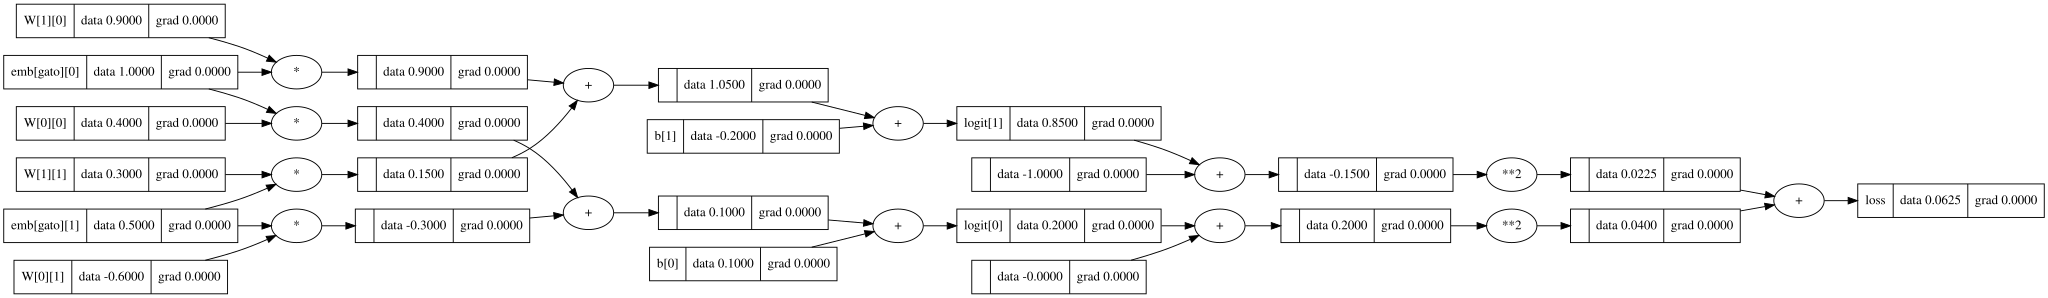

In [ ]:
draw_dot(loss)

### Backward

Uma linha, e todos os `grad` aparecem.

In [ ]:
loss.backward()

print("[DEPOIS do backward]")
print("  embedding (linha de 'gato'):", [round(v.grad, 4) for v in rede.emb("gato")])
print("  W[0]:                       ", [round(w.grad, 4) for w in rede.lin.W[0]])
print("  W[1]:                       ", [round(w.grad, 4) for w in rede.lin.W[1]])
print("  b:                          ", [round(x.grad, 4) for x in rede.lin.b])
print("  logits:                     ", [round(l.grad, 4) for l in logits])

[DEPOIS do backward]
  embedding (linha de 'gato'): [-0.11, -0.33]
  W[0]:                        [0.4, 0.2]
  W[1]:                        [-0.3, -0.15]
  b:                           [0.4, -0.3]
  logits:                      [0.4, -0.3]


O **mesmo** grafo depois do backward. Só a coluna `grad` mudou:

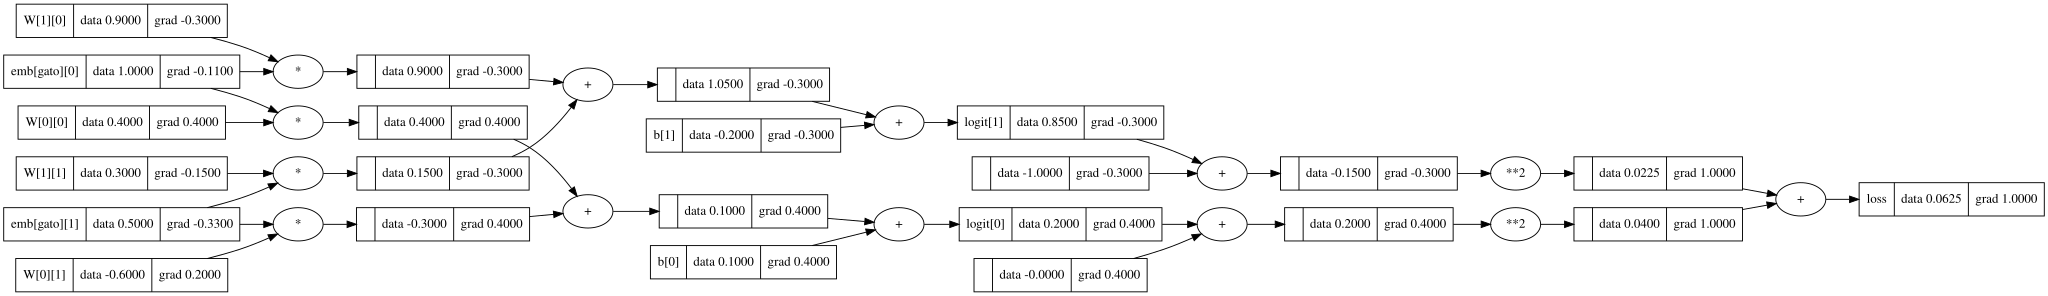

In [ ]:
draw_dot(loss)

Os dois diagramas são o mesmo grafo: mudou só a coluna `grad`.

Confira um número na mão. O gradiente do logit 0 é `2*(0.2 - 0.0) = 0.4`.
O `W[0][0]` multiplica `emb[gato][0]`, que vale `1.0`, então o gradiente dele
é `0.4 * 1.0 = 0.4`. O `W[0][1]` multiplica `0.5`, então sai `0.4 * 0.5 = 0.2`.

E repare: **nenhum peso mudou de valor.** O `backward()` só preencheu `grad`.

In [ ]:
# Quem altera os pesos é o passo de atualização, e ele é outro código.
lr = 0.1
w00 = rede.lin.W[0][0]
print("W[0][0]  antes:", round(w00.data, 4), " grad:", round(w00.grad, 4))

for p in rede.parameters():
    p.data += -lr * p.grad

print("W[0][0] depois:", round(w00.data, 4))
print("confere? 0.4 - 0.1*0.4 =", round(0.4 - 0.1 * 0.4, 4))

W[0][0]  antes: 0.4  grad: 0.4
W[0][0] depois: 0.36
confere? 0.4 - 0.1*0.4 = 0.36


## Intervenção A — trocar o alvo

Mesmos pesos, mesma palavra, mesmo forward. Só o alvo muda.

In [ ]:
for alvo in (1, 0):
    r = RedeMinima(VOCAB, dim=2, nout=2)
    lg = r("gato")
    l = erro_quadratico(lg, alvo)
    l.backward()
    print(f"alvo={alvo}  logits={[round(x.data,3) for x in lg]} (iguais!)"
          f"  loss={l.data:.4f}")
    print(f"          grad embedding: {[round(v.grad,4) for v in r.emb('gato')]}")

alvo=1  logits=[0.2, 0.85] (iguais!)  loss=0.0625
          grad embedding: [-0.11, -0.33]
alvo=0  logits=[0.2, 0.85] (iguais!)  loss=1.3625
          grad embedding: [0.89, 1.47]


Os logits são idênticos nos dois casos — a rede pensa a mesma coisa.
O que mudou foi o que consideramos certo, e isso inverteu o sinal de todo o
ajuste.

## Intervenção B — mexer num peso

In [ ]:
for delta in (0.0, 0.10, 0.15):
    r = RedeMinima(VOCAB, dim=2, nout=2)
    r.lin.W[1][0].data += delta      # empurra o peso na direção que o gradiente pediu
    lg = r("gato")
    l = erro_quadratico(lg, alvo=1)
    l.backward()
    print(f"W[1][0] += {delta:<5} ->  logit[1]={lg[1].data:.3f}"
          f"   loss={l.data:.4f}   grad de W[1][0]={r.lin.W[1][0].grad:+.4f}")

W[1][0] += 0.0   ->  logit[1]=0.850   loss=0.0625   grad de W[1][0]=-0.3000
W[1][0] += 0.1   ->  logit[1]=0.950   loss=0.0425   grad de W[1][0]=-0.1000
W[1][0] += 0.15  ->  logit[1]=1.000   loss=0.0400   grad de W[1][0]=+0.0000


A loss caiu **e o gradiente encolheu**. O gradiente não mede o tamanho do
erro: mede o quanto ainda vale a pena mexer naquele peso. Perto do acerto,
vale pouco — e o passo fica curto sozinho, sem ninguém programar isso.